# Helmholtz Gelichung

Dieses Notebook benutzt das dolfinx interface von FEniCS um die Helmholtz Gleichung in einem eindimensionalen Intervall $0<x<L$

\begin{equation*}
p''(x) + k^2p(x) = 0
\end{equation*}

mit den Randbedingungen $p(0)=p_{in}$ (Druckvorgabe an einem Ende) und $p'(L)=0$ (Reflektion am anderen Ende) zu lösen.
Es handelt sich um eine Idealisierung der Geometrie des Gehörganges in dem Fall, dass sich hinter dem Trommelfell Flüssigkeit befindet, da sich dieses dann ähnlich wie eine feste Wand verhält.


## Installation in Google Colab und Imports

In [2]:
%%capture
!wget "https://fem-on-colab.github.io/releases/fenicsx-install-release-real.sh" -O "/tmp/fenicsx-install.sh"
!bash "/tmp/fenicsx-install.sh"

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpi4py import MPI
from dolfinx import mesh, fem
from dolfinx.fem.petsc import LinearProblem
import ufl
from petsc4py import PETSc

## Physikalische Parameter

In [4]:
L = 0.025          # Länge Gehörgang [m]
c = 343.0          # Schallgeschwindigkeit [m/s]
f = 1000.0         # Frequenz [Hz]
p_in_value = 1.0   # Druck am Eingang [Pa]

k_value = 2.0 * np.pi * f / c # Wellenzahl

## Mesh

Das Intervall $[0,L]$ wird in $N$ Segmente diskretisiert.

In [5]:
N = 1000
domain = mesh.create_interval(MPI.COMM_WORLD, N, [0.0, L])

## Funktionsraum \& Randbedingungen

In [6]:
V = fem.functionspace(domain, ("Lagrange", 1))

p = ufl.TrialFunction(V) # trial function
v = ufl.TestFunction(V)  # test function

In [7]:
k = fem.Constant(domain, PETSc.ScalarType(k_value)) # allows to treat the parameters symbolically
zero = fem.Constant(domain, PETSc.ScalarType(0.0))

In [8]:
def entrance_boundary(x):
    return np.isclose(x[0], 0.0)

entrance_dofs = fem.locate_dofs_geometrical(V, entrance_boundary)

p_in = fem.Constant(domain, PETSc.ScalarType(p_in_value))
bc_entrance = fem.dirichletbc(p_in, entrance_dofs, V) # boundary condition at x=0

## Schwache Form

Leiten Sie die schwache Form her und Formulieren Sie das Variationsproblem.
Implementieren Sie unten ihr Ergebnis.


In [9]:
a = (ufl.grad(p)[0] * ufl.grad(v)[0] - k**2 * p * v) * ufl.dx
L_form = fem.Constant(domain, PETSc.ScalarType(0.0)) * v * ufl.dx

## FEM Löser

In [10]:
p_h = fem.Function(V) # approximant of p(x)

problem = LinearProblem(a, L_form, bcs=[bc_entrance], u=p_h, petsc_options={ "ksp_type": "preonly", "pc_type": "lu",}, petsc_options_prefix="helmholtz_1d",)
problem.solve()

Coefficient(FunctionSpace(Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (1,)), 0), Basix element (P, interval, 1, gll_warped, unset, False, float64, [])), 0)

## Numerische Lösung

Bestimmen Sie die analytische Lösung des Problems und implementieren Sie diese im nächsten Code Block als Test der Simulation.

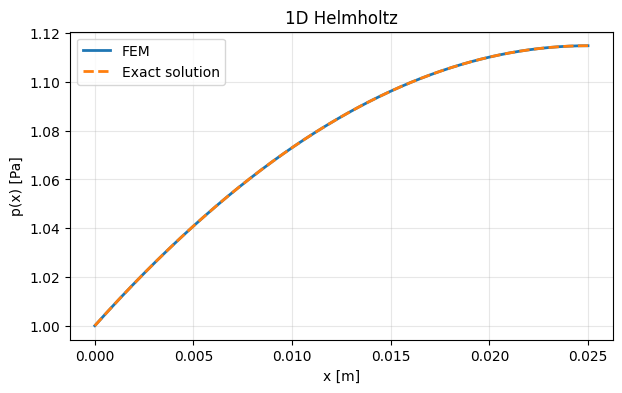

In [14]:
x = domain.geometry.x[:, 0]
p_vals = p_h.x.array.real

order = np.argsort(x)

p_exact = p_in_value * np.cos(k_value * (L - x)) / np.cos(k_value * L)

plt.figure(figsize=(7, 4))
plt.plot(x[order], p_vals[order], linewidth=2, label="FEM")
plt.plot(x[order], p_exact, "--", linewidth=2, label="Exact solution")
plt.xlabel("x [m]")
plt.ylabel("p(x) [Pa]")
plt.title("1D Helmholtz")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()